In [1]:
library(dplyr)       # for data manipulation
library(ggplot2)     # for data visualization
library(stringr)     # for string functionality
library(cluster)     # for general clustering algorithms
library(factoextra)  # for visualizing cluster results
library(readr)      # for reading


Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'cluster' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'factoextra' wurde unter R Version 4.4.3 erstellt"
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [10]:
# read dataset and clean
df <- read_csv("data/merged_county_data.csv")
df <- df %>% filter(!County %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"))
df_raw <- df
County <- df$County
df$density <- df$population*1.0/df$AREA_SQMI
df <- df %>% select(-c("County", "PHR", "outbreak", "AREA_SQMI"), -starts_with("M_"), -starts_with("MP_"), -starts_with("E_"), -starts_with("EPL_"), -starts_with("SPL_"), -starts_with("RPL_"), -starts_with("F_"))
df <- df[,colSums(is.na(df)) == 0]
df <- df %>% select(-c("EP_MINRTY", "EP_HISP", "EP_AFAM", "EP_POV150", "EP_UNINSUR"))
df <- as.data.frame(scale(df))  
summary(df)
df

Rows: 254 Columns: 165
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (163): cve, outbreak, enrollment, population, PHR, pct_hispanic, pct_bla...
lgl   (1): median_income

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


      cve            population       pct_hispanic       pct_black      
 Min.   :-1.4159   Min.   :-0.2849   Min.   :-1.5568   Min.   :-0.9753  
 1st Qu.:-0.6642   1st Qu.:-0.2706   1st Qu.:-0.7136   1st Qu.:-0.7809  
 Median :-0.1446   Median :-0.2415   Median :-0.3487   Median :-0.3353  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4835   3rd Qu.:-0.1569   3rd Qu.: 0.6289   3rd Qu.: 0.3533  
 Max.   : 5.9193   Max.   :11.0526   Max.   : 2.6901   Max.   : 4.3714  
   pct_white        pct_poverty       pct_uninsured      pct_college     
 Min.   :-3.0345   Min.   :-1.98038   Min.   :-3.3219   Min.   :-2.4539  
 1st Qu.:-0.5371   1st Qu.:-0.65778   1st Qu.:-0.6163   1st Qu.:-0.6677  
 Median : 0.1321   Median :-0.07583   Median :-0.0537   Median :-0.1434  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.7522   3rd Qu.: 0.46644   3rd Qu.: 0.4551   3rd Qu.: 0.4511  
 Max.   : 1.8348   Max.   : 4.31522   Max.   

cve,population,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,EP_UNEMP,...,EP_CROWD,EP_NOVEH,EP_GROUPQ,EP_NOINT,EP_ASIAN,EP_AIAN,EP_NHPI,EP_TWOMORE,EP_OTHERRACE,density
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-0.134475445,-0.14842530,-0.7004673,2.03830292,-0.345687732,0.400308508,0.29855684,-0.7266179,0.09608508,-0.34822191,...,0.41454893,0.60300678,3.10490121,-0.09437215,-0.20294647,0.9458269,0.1756344,1.36375308,0.06878959,-0.20428937
-0.452300816,-0.24014338,0.9554941,-0.71607291,-0.382436959,0.523751660,1.06177895,-0.4686497,0.21326200,-0.83030117,...,0.56098090,-1.25906357,-0.60816486,-1.25049826,-0.29570079,-0.5320276,-0.3801706,-0.90181048,-0.31337480,-0.31620859
-0.154654834,-0.08682147,-0.5300649,0.98515922,-0.033319299,0.047613787,0.14199845,-0.4462177,0.21326200,0.49541678,...,0.01186099,0.26099386,-0.09540812,-0.98163172,-0.11019214,0.3124607,-0.3801706,0.72474797,0.06878959,-0.06829116
-0.376628108,-0.22627691,-0.3727705,-0.76467954,0.793538315,-0.093464101,-0.81692164,0.7763273,0.56479277,-0.14735556,...,0.41454893,0.07098668,-0.48439599,-1.06229168,0.26082516,0.5235828,-0.3801706,-0.08853125,-0.69553919,-0.08560910
-0.053757891,-0.26472011,-1.1461350,-0.73227512,1.528522861,-1.186817734,-0.60165386,0.3949830,-0.25544569,-0.66960808,...,-0.83012288,-0.91705065,-0.59048359,-0.22880542,-0.43483228,0.3124607,-0.3801706,0.43429111,-0.69553919,-0.32461904
1.227633283,-0.28096563,-1.0325334,-0.87809501,1.589771573,-0.922296694,-2.49992425,0.5968711,-0.60697646,-1.83463295,...,-1.08637884,-1.86708654,-0.18381445,-0.92785842,-0.48120944,1.7903153,-0.3801706,-0.43707949,-0.69553919,-0.34505545
-0.871023128,-0.16652648,1.3006681,-0.78088175,-1.074547406,0.417943244,0.49425481,-0.6929699,0.21326200,0.65610986,...,1.51278876,0.22299242,-0.57280233,-0.43045532,-0.29570079,-0.5320276,-0.3801706,-0.49517086,-0.31337480,-0.23989821
0.375054116,-0.21038259,-0.3421854,0.30466637,0.162676580,-0.111098837,-0.05369953,0.3613349,0.09608508,-0.38839519,...,0.63419689,-0.53703629,-0.55512106,0.12072107,-0.29570079,-0.3209056,-0.3801706,-0.14662263,0.83311837,-0.21912108
-1.012278848,-0.26906811,1.3268838,-0.82948838,0.450545527,-0.675410389,2.27510641,-0.7490499,3.14268509,-1.07134080,...,0.52437291,3.14910297,-0.25453952,0.10727775,0.07531651,1.5791932,-0.3801706,-0.55326224,-0.69553919,-0.32822662


In [115]:
pca_df <- prcomp(df)
summary(pca_df)
names(pca_df)
pca_df$center
pca_df$rotation

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     2.4353 2.2428 1.54094 1.26537 1.14634 1.12664 1.04668
Proportion of Variance 0.2045 0.1734 0.08188 0.05521 0.04531 0.04377 0.03778
Cumulative Proportion  0.2045 0.3780 0.45983 0.51504 0.56036 0.60413 0.64190
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     1.02856 0.99222 0.96961 0.94629 0.87797 0.81385 0.77753
Proportion of Variance 0.03648 0.03395 0.03242 0.03088 0.02658 0.02284 0.02085
Cumulative Proportion  0.67839 0.71233 0.74475 0.77563 0.80221 0.82505 0.84590
                          PC15    PC16    PC17    PC18    PC19   PC20    PC21
Standard deviation     0.77072 0.76053 0.72592 0.66581 0.63980 0.6188 0.58043
Proportion of Variance 0.02048 0.01995 0.01817 0.01529 0.01412 0.0132 0.01162
Cumulative Proportion  0.86638 0.88632 0.90450 0.91978 0.93390 0.9471 0.95872
                          PC22    PC23

[1] "sdev"     "rotation" "center"   "scale"    "x"

cve       population     pct_hispanic        pct_black 
    3.588241e-16    -8.881784e-19    -5.577760e-16     3.606004e-16 
       pct_white      pct_poverty    pct_uninsured      pct_college 
   -1.492140e-16     1.154632e-15    -1.260769e-15    -1.096900e-15 
pct_foreign_born         EP_UNEMP         EP_HBURD        EP_NOHSDP 
    2.378098e-16     3.883560e-16     5.824230e-16     2.826184e-15 
        EP_AGE65         EP_AGE17        EP_DISABL        EP_SNGPNT 
    1.584510e-15    -3.271161e-15     5.170309e-16    -2.415845e-16 
       EP_LIMENG         EP_MUNIT        EP_MOBILE         EP_CROWD 
    8.260059e-17    -5.204726e-16     2.655653e-16    -1.182165e-15 
        EP_NOVEH        EP_GROUPQ         EP_NOINT         EP_ASIAN 
   -6.006758e-16    -2.859935e-16     1.103895e-15    -8.260059e-17 
         EP_AIAN          EP_NHPI       EP_TWOMORE     EP_OTHERRACE 
   -7.531753e-16     1.159073e-16     3.437250e-16    -5.648815e-16 
         density 
   -6.461498e-17

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29
cve,0.210885364,-0.011434927,0.14651546,-0.118849466,0.095864934,-0.262423714,0.084283184,0.41645926,-0.2576536849,-0.290696449,...,-0.039946502,-0.094384183,-0.251766126,0.100183368,0.112819462,0.091933899,0.106310379,-0.139400118,-0.001350531,0.062471703
population,-0.017695450,0.347676589,-0.06525533,0.230380095,0.174583015,0.020023256,0.059301481,0.16619073,-0.1458602555,-0.008585106,...,-0.117605195,0.017935386,0.031011890,-0.055603551,0.052360800,-0.205792520,0.011380545,-0.073153806,-0.635552343,0.040632186
pct_hispanic,-0.360381072,0.008798596,0.14529817,0.156326901,-0.091344228,-0.062394952,-0.115974101,-0.08712875,0.0596558428,0.071709298,...,-0.189486781,0.005122234,-0.051556628,0.299376331,0.167064769,0.033923249,-0.057993508,-0.020861429,0.054993680,0.751648488
pct_black,0.032280078,0.177716919,-0.37582491,-0.175705593,-0.031785852,0.280679223,0.134446754,0.08059639,0.0171925593,-0.117687053,...,0.260568616,-0.305400643,0.106603306,0.124607245,-0.008670177,-0.021692859,0.036524519,0.064922639,-0.038478716,0.310539817
pct_white,0.334818729,-0.139359513,0.02502204,-0.098087771,0.126469933,-0.080965942,0.039907374,0.02567173,-0.0271114087,-0.085426090,...,0.200690046,0.222772881,0.072262646,-0.413847826,-0.290121060,-0.130680201,0.013559909,0.214989971,0.049251441,0.533169273
pct_poverty,-0.265673675,-0.051830898,-0.16285457,-0.151605543,0.255823052,-0.173203803,-0.215325548,-0.05582425,-0.0386900975,-0.071631702,...,0.022190343,-0.253366849,0.199602197,-0.235044115,-0.101562848,0.138153886,0.058696346,-0.041167808,0.012690666,0.030141612
pct_uninsured,-0.269274253,-0.058125442,0.04669599,-0.005148471,0.047537950,-0.201651820,0.012865076,0.37719717,-0.1742061658,-0.169598833,...,0.189649857,0.404685354,0.228483696,0.231398333,0.087125708,0.116214358,-0.188770800,0.037539544,-0.005555670,-0.071275142
pct_college,0.195708517,0.275818487,0.12683230,0.107330953,0.075318479,-0.145954151,-0.074090807,-0.06066429,-0.0980725481,-0.045769719,...,-0.058287799,-0.090435313,0.334592066,0.285117213,-0.347156523,-0.317465376,-0.181803956,0.254041741,-0.075842512,-0.028427133
pct_foreign_born,-0.027347819,0.157068309,-0.06065114,0.133093191,-0.285200982,-0.311136832,0.351409794,-0.19192167,-0.1291792304,0.404122659,...,0.054548154,0.006752469,0.059564804,-0.213294790,0.056034420,-0.036259195,-0.070777411,0.056310783,0.005428643,-0.033494012
EP_UNEMP,-0.100010944,0.011944513,-0.35834522,-0.149195693,0.219274767,-0.065728787,0.177679195,0.24156930,0.1981483578,0.032574871,...,0.107822683,0.086271894,-0.011005028,-0.096984881,-0.050908259,0.006124566,-0.060731338,-0.039797141,-0.001238616,0.003208057


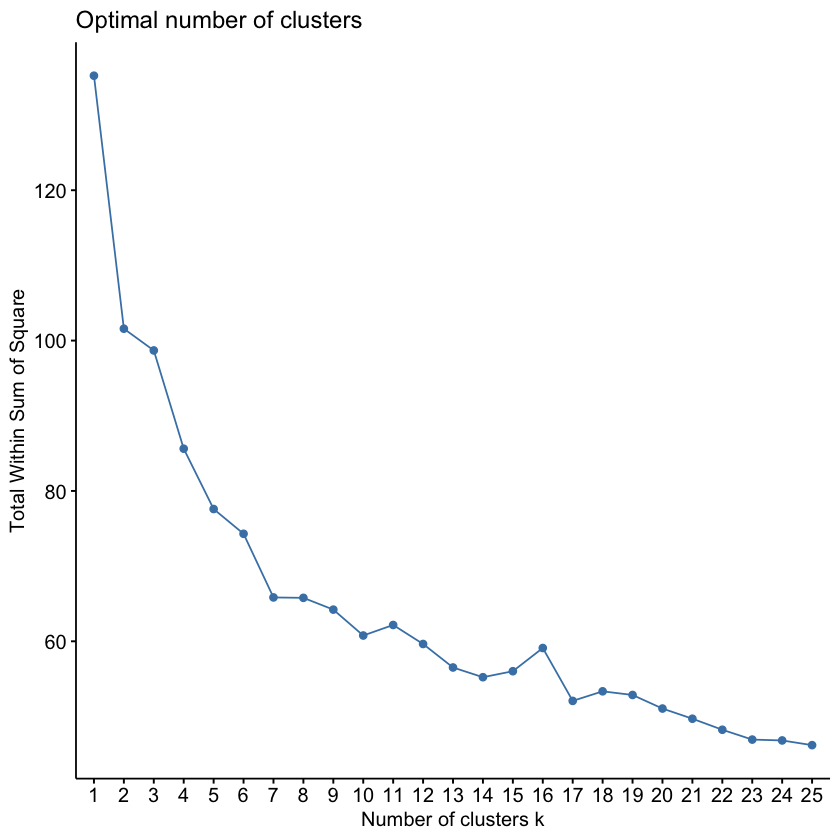

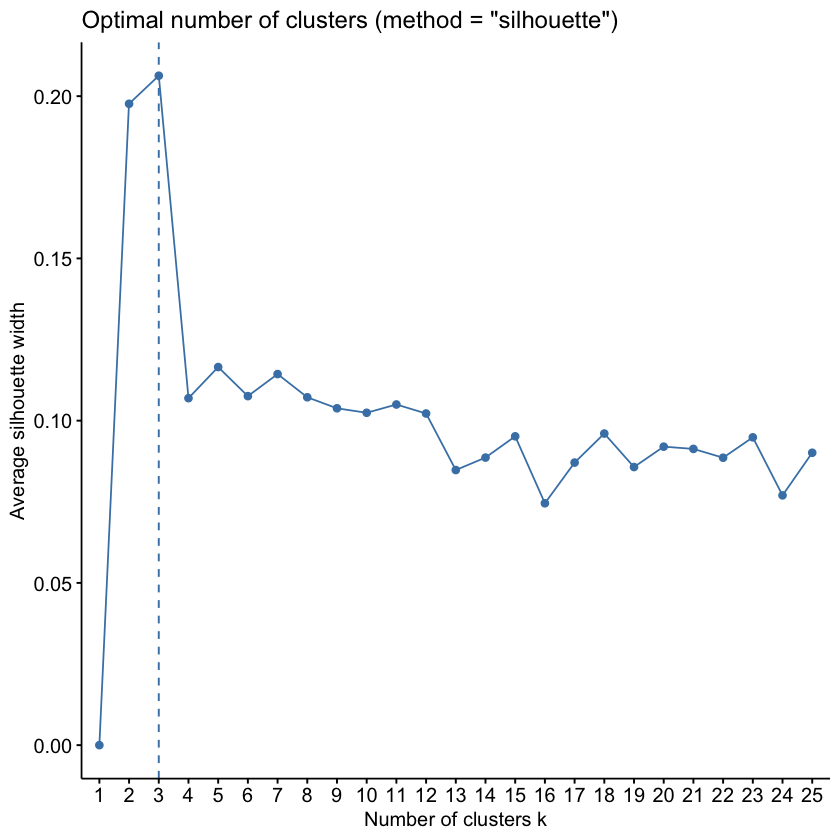

In [3]:
# inspect optimal clusters
fviz_nbclust(
  df,
  kmeans, 
  k.max = 25,
  method = "wss",
  diss = get_dist(df, method = "spearman")
)

fviz_nbclust(
  df, 
  kmeans, 
  method = "silhouette", 
  k.max = 25, 
  nstart = 25)

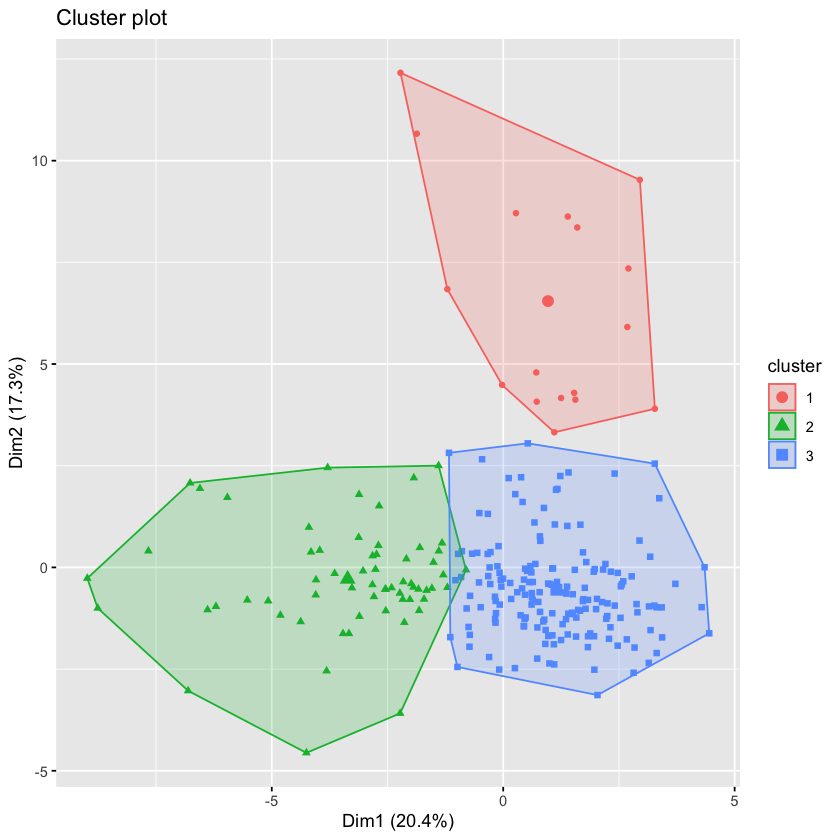

In [4]:
set.seed(100)
km <- kmeans(df, centers = 3, nstart = 25)
fviz_cluster(km, data = df, geom = "point", ellipse.type = "convex")

In [5]:
# get PCA coords
pca_coords <- as.data.frame(pca_out$x[, 1:2])
pca_coords$cluster <- factor(km$cluster)
pca_coords$outbreak <- df_raw$outbreak  # raw outbreak count

p <- fviz_cluster(km, data = df, geom = "point", ellipse.type = "convex") +
  theme_minimal()

# extract the PCA coords fviz already computed
plot_data <- p$data

# add outbreak from df_raw (make sure row order matches)
plot_data$outbreak <- df_raw$outbreak

# rebuild with sized points on top
p + 
  geom_point(data = plot_data %>% filter(outbreak > 0),
             aes(x = x, y = y, size = outbreak),
             color = "black", alpha = 0.7) +
  scale_size_continuous(range = c(2, 10), name = "Outbreak cases")

ERROR: Error in eval(expr, envir, enclos): Objekt 'pca_out' nicht gefunden


In [6]:
# Analyzing results
# see centroid
centroids <- km$centers
print(centroids)
# see what loads heavily on PC1
pca_out <- prcomp(df)
names(pca_out)
sort(pca_out$rotation[, 1], decreasing = TRUE) %>% head(10)
sort(pca_out$rotation[, 1], decreasing = FALSE) %>% head(10)

          cve population pct_hispanic   pct_black  pct_white pct_poverty
1  0.05574497  2.5223173   -0.2154760  1.13288526 -0.6994891  -0.6287302
2 -0.59852131 -0.1547206    1.4070569 -0.48332686 -1.0824222   0.7678388
3  0.21623046 -0.1948941   -0.4998911  0.06582672  0.4710819  -0.2216790
  pct_uninsured pct_college pct_foreign_born    EP_UNEMP   EP_HBURD  EP_NOHSDP
1    -0.6546074  2.11169207       1.10932083  0.06296333  0.9226619 -0.8383684
2     0.9794615 -0.67854930       0.03842659  0.11664022  0.1081629  1.2123863
3    -0.2975162  0.04029318      -0.12517253 -0.04952183 -0.1323501 -0.3654593
    EP_AGE65   EP_AGE17  EP_DISABL   EP_SNGPNT    EP_LIMENG   EP_MUNIT
1 -1.1014057  0.2665331 -1.1812799  0.05122253 -0.006079104  2.5487011
2 -0.6689238  0.8473003 -0.3250307  0.69490194  1.010417159 -0.0897760
3  0.3580359 -0.3406528  0.2385805 -0.26264474 -0.373840802 -0.2216002
    EP_MOBILE    EP_CROWD   EP_NOVEH   EP_GROUPQ    EP_NOINT   EP_ASIAN
1 -1.29070996 -0.08719594 -0.2732616

[1] "sdev"     "rotation" "center"   "scale"    "x"

pct_white          cve     EP_AGE65  pct_college   EP_TWOMORE    EP_DISABL 
  0.33481873   0.21088536   0.20045796   0.19570852   0.16563618   0.05428499 
    EP_ASIAN    pct_black EP_OTHERRACE      EP_NHPI 
  0.03485572   0.03228008   0.03203957   0.01849488

pct_hispanic     EP_NOHSDP     EP_LIMENG pct_uninsured   pct_poverty 
   -0.3603811    -0.3380666    -0.3043091    -0.2692743    -0.2656737 
    EP_SNGPNT      EP_CROWD      EP_AGE17      EP_NOVEH      EP_NOINT 
   -0.2422412    -0.2348407    -0.2077236    -0.1987022    -0.1791407

In [9]:
# attach cluster assignments
df$cluster <- km$cluster
df$county <- County
df
# look at means of original variables by cluster
sum <- df %>%
  group_by(cluster) %>%
  summarise(across(where(is.numeric), mean))

cluster_label <- df %>% select(c(cluster, county))
write.csv(cluster_label, "data/cluster_labels.csv", row.names = FALSE)
write.csv(sum, "data/cluster_means.csv", row.names = FALSE)

cve,population,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,EP_UNEMP,...,EP_GROUPQ,EP_NOINT,EP_ASIAN,EP_AIAN,EP_NHPI,EP_TWOMORE,EP_OTHERRACE,density,cluster,county
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
-0.134475445,-0.14842530,-0.7004673,2.03830292,-0.345687732,0.400308508,0.29855684,-0.7266179,0.09608508,-0.34822191,...,3.10490121,-0.09437215,-0.20294647,0.9458269,0.1756344,1.36375308,0.06878959,-0.20428937,3,Anderson
-0.452300816,-0.24014338,0.9554941,-0.71607291,-0.382436959,0.523751660,1.06177895,-0.4686497,0.21326200,-0.83030117,...,-0.60816486,-1.25049826,-0.29570079,-0.5320276,-0.3801706,-0.90181048,-0.31337480,-0.31620859,2,Andrews
-0.154654834,-0.08682147,-0.5300649,0.98515922,-0.033319299,0.047613787,0.14199845,-0.4462177,0.21326200,0.49541678,...,-0.09540812,-0.98163172,-0.11019214,0.3124607,-0.3801706,0.72474797,0.06878959,-0.06829116,3,Angelina
-0.376628108,-0.22627691,-0.3727705,-0.76467954,0.793538315,-0.093464101,-0.81692164,0.7763273,0.56479277,-0.14735556,...,-0.48439599,-1.06229168,0.26082516,0.5235828,-0.3801706,-0.08853125,-0.69553919,-0.08560910,3,Aransas
-0.053757891,-0.26472011,-1.1461350,-0.73227512,1.528522861,-1.186817734,-0.60165386,0.3949830,-0.25544569,-0.66960808,...,-0.59048359,-0.22880542,-0.43483228,0.3124607,-0.3801706,0.43429111,-0.69553919,-0.32461904,3,Archer
1.227633283,-0.28096563,-1.0325334,-0.87809501,1.589771573,-0.922296694,-2.49992425,0.5968711,-0.60697646,-1.83463295,...,-0.18381445,-0.92785842,-0.48120944,1.7903153,-0.3801706,-0.43707949,-0.69553919,-0.34505545,3,Armstrong
-0.871023128,-0.16652648,1.3006681,-0.78088175,-1.074547406,0.417943244,0.49425481,-0.6929699,0.21326200,0.65610986,...,-0.57280233,-0.43045532,-0.29570079,-0.5320276,-0.3801706,-0.49517086,-0.31337480,-0.23989821,2,Atascosa
0.375054116,-0.21038259,-0.3421854,0.30466637,0.162676580,-0.111098837,-0.05369953,0.3613349,0.09608508,-0.38839519,...,-0.55512106,0.12072107,-0.29570079,-0.3209056,-0.3801706,-0.14662263,0.83311837,-0.21912108,3,Austin
-1.012278848,-0.26906811,1.3268838,-0.82948838,0.450545527,-0.675410389,2.27510641,-0.7490499,3.14268509,-1.07134080,...,-0.25453952,0.10727775,0.07531651,1.5791932,-0.3801706,-0.55326224,-0.69553919,-0.32822662,2,Bailey


In [ ]:
<|the number of clusters
$K$ must be specified in advance. To determine the optimal $K$, we use the
elbow method and the silhouette score. The elbow method plots the
within-cluster sum of squares regarding $K$, defined as
\begin{align*}
\mathrm{WCSS}(K) = \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \bar x_k \rVert^2,
\end{align*}
where $C_k$ denotes the $k$-th cluster and $\bar x_k$ its centroid. As $K$
increases, WCSS decreases monotonically, since adding clusters can only
tighten the fit. The elbow method plots $\mathrm{WCSS}(K)$ against $K$ and
identifies the point at which the marginal reduction in WCSS sharply
diminishes; beyond this ``elbow,'' additional clusters yield little gain in
compactness and risk overfitting the data.

We validate the candidate $K$ using the silhouette score, which assesses both
cluster cohesion and separation. For each observation $i$, let $a(i)$ be the average distance to all other points in the same cluster and $b(i)$ be average distance to the nearest neighboring cluster. The silhouette metric $s(i) \in [-1, 1]$ is defined as
\begin{align*}
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
\end{align*}
A positive silhouette score close to $1$ indicates a correctly clustered observation, with 0 suggesting it lies between clusters, and negative values indicating misclassification. We then obtain an overall silhouette score by taking mean of $s(i)$ across all observations and prefer $K$ that yields a high average silhouette score. From Figure \ref{fig:k_opt}, we notice that K=3 is identified as optimal point, and $K=4$ introduces a sharp drop in silhouette score, confirming that $K=3$ is the best choice for our clustering solution
. By averaging $s(i)$ across all observations, we obtain an overall silhouette score for the clustering solution. We prefer the $K$ that yields a high average silhouette score while remaining consistent with the elbow plot, ensuring both compactness and separation in our clusters.
values near $1$ indicate that the observation
is well matched to its own cluster and poorly matched to neighboring clusters,
values near $0$ suggest the observation lies between clusters, and negative
values indicate possible misassignment. The average silhouette score across
all observations summarizes overall clustering quality, so we prefer the $K$
that yields a high average silhouette while remaining consistent with the
elbow plot.